# Learner Activity: PyTorch MNIST CNN, Autoencoder, and Latent Space

This guided lab introduces image workflows in PyTorch. You will load MNIST, inspect image tensors, apply a simple kernel, train a CNN classifier, train an autoencoder, and visualize a 2D latent space.


## How To Use This Notebook

This is a two-session guided challenge for learners who only started PyTorch yesterday.

Look for the nine code cells labeled `TODO 1` through `TODO 9`. Those are the only required code blocks you need to fill in. Most TODOs are fill-in-the-blank: read the nearby comments, choose the right function or parameter, and keep the PyTorch workflow in order.

Session 1 focuses on supervised image classification:

1. Load MNIST as tensors.
2. Inspect image batch shapes.
3. Apply a manual kernel.
4. Build, train, and evaluate a CNN classifier.

Session 2 focuses on unsupervised representation learning:

5. Build and train an autoencoder.
6. Compare original and reconstructed digits.
7. Plot the 2D latent space.

Cells without a `TODO` banner are setup, helper, visualization, or reflection cells. Run them, read the comments, and pause at the understanding checks.

## Two 3-Hour Session Flow

### Session 1: Image Tensors, Kernels, and CNN Classification

- 25-30 min: load MNIST, inspect tensors, and visualize sample digits
- 30-40 min: manual kernel demo and image-shape intuition
- 45-55 min: build the CNN and discuss layer shapes
- 40-50 min: train, evaluate, and inspect predictions
- 10-15 min: Session 1 checkpoint

### Session 2: Autoencoders and Latent Space

- 30-40 min: autoencoder idea, encoder/decoder shape walkthrough
- 40-50 min: train reconstruction model and inspect outputs
- 35-45 min: encode test images and plot latent space
- 30-40 min: discuss clusters, overlap, and representation tradeoffs
- 15-20 min: reflection and wrap-up

Key message: the PyTorch training loop is familiar from yesterday. The new skill is reading image tensors and choosing the right model shape for the task.

In [80]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

try:
    from torchvision import datasets, transforms
except ImportError as exc:
    raise ImportError(
        "torchvision is required for this activity. Install it with: pip install torchvision"
    ) from exc


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("data")
TRAIN_LIMIT = 12_000
TEST_LIMIT = 2_000
BATCH_SIZE = 64
EVAL_BATCH_SIZE = 256
CNN_EPOCHS = 15
AUTOENCODER_EPOCHS = 20
LEARNING_RATE = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## Session 1: Image Tensors, Kernels, and CNN Classification

Goal for this session: connect yesterday's PyTorch training-loop pattern to image data. Learners should leave able to explain MNIST tensor shape, what a kernel does, and how a CNN produces 10 digit logits.

## 1. Load MNIST

MNIST images are 28 by 28 grayscale handwritten digits. `transforms.ToTensor()` converts each image into a PyTorch tensor with shape `[channels, height, width]` and pixel values between 0 and 1.


In [81]:
# TODO 1: Load real MNIST with torchvision.
# Fill in the blanks one line at a time.
# Use this function to convert PIL images into PyTorch tensors: transforms.ToTensor()

transform = transforms.ToTensor()# Which torchvision transform converts an image to a tensor?

# Use datasets.MNIST(...). Which train parameter should you put for the training split?
full_train_ds = datasets.MNIST(
    DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

# Use datasets.MNIST(...). Which train parameter should you put for the test split?
full_test_ds = datasets.MNIST(
    DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)

# Use Subset(dataset, range(limit)) so classroom training stays fast.
train_ds = Subset(full_train_ds, range(TRAIN_LIMIT))
test_ds = Subset(full_test_ds, range(TEST_LIMIT))

# Fill in the DataLoader parameters.
# Training usually shuffles. Evaluation usually does not shuffle.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
test_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f"Training examples: {len(train_ds):,}")
print(f"Test examples: {len(test_ds):,}")

Training examples: 12,000
Test examples: 2,000


### Understanding Check: Dataset Loading

- How many channels do MNIST images have?
- ANSWER: The MNIST images only have 1 channel because they are grayscale images where each image only contains intensity values instead of RGB color channels.
- What does the `ToTensor()` transform do to the pixel values?
- ANSWER: The 'ToTensor()' transform and scales 0-255 to 0-1. This normalization can help the model train more efficiently and consistently.

In [82]:
# TODO 2: Inspect one image batch.
# Use this pattern to get one batch: next(iter(train_loader))
# Then fill in the print statements with the right tensor attributes.

images, labels = next(iter(train_loader))

print("images shape:", images.shape)      # Which attribute shows [batch, channels, height, width]?
print("labels shape:", labels.shape)      # Which attribute shows the label vector shape?
print("image dtype:", images.dtype)       # Which attribute shows tensor data type?
print("label dtype:", labels.dtype)
print("pixel min/max:", images.min().item(), images.max().item())  # Use images.min().item() and images.max().item()
print("first 10 labels:", labels[:10].tolist())     # Use labels[:10].tolist()

assert images.ndim == 4
assert images.shape[1:] == (1, 28, 28)
assert labels.ndim == 1

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
image dtype: torch.float32
label dtype: torch.int64
pixel min/max: 0.0 1.0
first 10 labels: [3, 7, 5, 8, 3, 3, 8, 6, 4, 2]


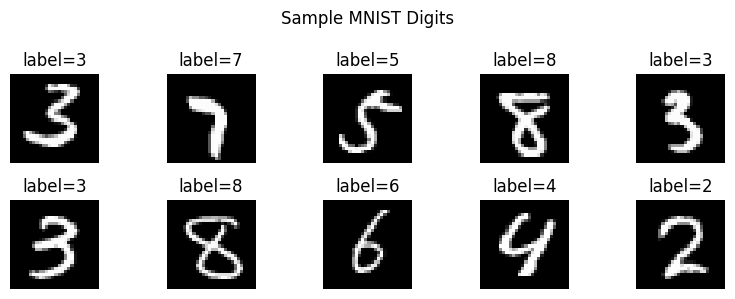

In [83]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3))
for ax, img, label in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"label={label.item()}")
    ax.axis("off")

fig.suptitle("Sample MNIST Digits")
plt.tight_layout()
plt.show()


## 2. Kernels

A kernel is a small grid of weights that slides across an image. The output is high where the local pixel pattern matches the kernel. This demo uses a hand-written edge-like kernel before we let a CNN learn its own kernels.


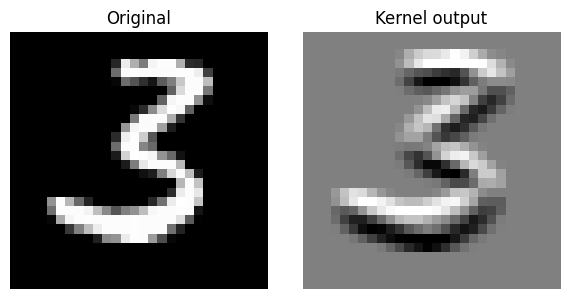

In [84]:
# TODO 3: Apply a manual 3x3 kernel to one digit.
# Fill in the 3 rows of the edge-like kernel shown in the lecture.
# Which function applies a 2D convolution? Use F.conv2d(...).

edge_kernel = torch.tensor(
    [
        [-1., -1., -1.],
        [0., 0., 0.],
        [1., 1., 1.],
    ]
).view(1, 1, 3, 3)

sample_image = images[0:1]
filtered_image = F.conv2d(sample_image, edge_kernel, padding=1)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(sample_image.squeeze(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(filtered_image.squeeze(), cmap="gray")
axes[1].set_title("Kernel output")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Understanding Check: Kernel Demo

- What changed after applying the kernel?
- ANSWER: Local features of the image was extracted. There are part of the image that were retained especially the horizontal part while the vertical part are discarded.

## 3. CNN Classifier

A CNN learns kernels instead of manually defining them. The convolution and pooling blocks keep spatial information for as long as possible, then the classifier converts learned features into 10 digit logits.


In [85]:
# TODO 4: Build a compact CNN classifier.
# Fill in the function parameters.
# Hint: MNIST has 1 input channel. The first conv block creates 16 channels.
# Hint: the second conv block goes from 16 channels to 32 channels.
# Hint: after two 2x2 pooling steps, 28 -> 14 -> 7, so the flattened size is 32 * 7 * 7.

cnn_model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=32*7*7, out_features=64),
    nn.ReLU(),
    nn.Linear(in_features=64, out_features=10),
).to(device)

print(cnn_model)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=64, bias=True)
  (8): ReLU()
  (9): Linear(in_features=64, out_features=10, bias=True)
)


In [86]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


with torch.no_grad():
    demo_logits = cnn_model(images[:4].to(device))

print("Trainable parameters:", f"{count_parameters(cnn_model):,}")
print("Demo logits shape:", tuple(demo_logits.shape))


Trainable parameters: 105,866
Demo logits shape: (4, 10)


### Understanding Check: CNN Shapes

Answer in 2-3 short sentences before training:

1. Why does MNIST use `Conv2d(1, ...)` for the first layer?
- ANSWER: MNIST images are grayscale that's why they only contain one color channel. Because of this, the first convolutional layer uses the first convolutional layer use in_channel=1.
2. Why does the final layer have 10 outputs?
- ANSWER: The final layer have 10 outputs because the model predicts digits from 0 to 9. Each output corresponds to one digit class.
3. Why is the flattened size `32 * 7 * 7` after two 2x2 pooling steps?
- ANSWER: The original image size is 28x28. After the 2x2 pooling operations, the spatial dimensions are reduced from 28->14->7, while the final convolution layer produces 32 channels, resulting in 32x7x7.


In [87]:
# TODO 5: Train the CNN classifier.
# Complete the standard PyTorch training-loop order:
# 1. clear old gradients
# 2. run the model forward
# 3. calculate loss
# 4. backpropagate
# 5. update weights

cnn_loss_fn = nn.CrossEntropyLoss()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)

cnn_history = []
for epoch in range(1, CNN_EPOCHS + 1):
    cnn_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        # Which optimizer method clears old gradients?
        cnn_optimizer.zero_grad()
        # Use the model like a function: cnn_model(batch_images)
        logits =  logits = cnn_model(batch_images)
        # CrossEntropyLoss compares logits to integer class labels.
        loss = cnn_loss_fn(logits, batch_labels)
        # Which loss method computes gradients?
        loss.backward()
        # Which optimizer method updates model weights?
        cnn_optimizer.step()

        running_loss += loss.item() * batch_labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == batch_labels).sum().item()
        total += batch_labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    cnn_history.append({"epoch": epoch, "loss": epoch_loss, "accuracy": epoch_acc})
    print(f"Epoch {epoch}: train loss={epoch_loss:.4f}, train accuracy={epoch_acc:.3f}")

Epoch 1: train loss=0.7379, train accuracy=0.779
Epoch 2: train loss=0.2135, train accuracy=0.939
Epoch 3: train loss=0.1329, train accuracy=0.961
Epoch 4: train loss=0.1043, train accuracy=0.968
Epoch 5: train loss=0.0785, train accuracy=0.975
Epoch 6: train loss=0.0616, train accuracy=0.982
Epoch 7: train loss=0.0531, train accuracy=0.985
Epoch 8: train loss=0.0473, train accuracy=0.985
Epoch 9: train loss=0.0338, train accuracy=0.989
Epoch 10: train loss=0.0320, train accuracy=0.990
Epoch 11: train loss=0.0256, train accuracy=0.992
Epoch 12: train loss=0.0224, train accuracy=0.993
Epoch 13: train loss=0.0197, train accuracy=0.993
Epoch 14: train loss=0.0167, train accuracy=0.995
Epoch 15: train loss=0.0145, train accuracy=0.996


In [88]:
# TODO 6: Evaluate the CNN classifier.
# Fill in the forward pass, loss, and class prediction.
# Hint: use logits.argmax(dim=1) to convert logits into predicted classes.

cnn_model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        logits = cnn_model(batch_images) # Use cnn_model on batch_images.
        loss = cnn_loss_fn(logits, batch_labels) # Use cnn_loss_fn on logits and batch_labels.
        preds = logits.argmax(dim=1)# Which dimension contains the 10 class logits?

        test_loss += loss.item() * batch_labels.size(0)
        correct += (preds == batch_labels).sum().item()
        total += batch_labels.size(0)

test_loss = test_loss / total
test_accuracy = correct / total
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.3f}")

Test loss: 0.0058
Test accuracy: 0.999


In [89]:
def collect_predictions(model: nn.Module, loader: DataLoader, max_batches: int = 6):
    model.eval()
    all_images, all_labels, all_preds = [], [], []

    with torch.no_grad():
        for batch_idx, (batch_images, batch_labels) in enumerate(loader):
            logits = model(batch_images.to(device))
            preds = logits.argmax(dim=1).cpu()
            all_images.append(batch_images.cpu())
            all_labels.append(batch_labels.cpu())
            all_preds.append(preds)

            if batch_idx + 1 >= max_batches:
                break

    return torch.cat(all_images), torch.cat(all_labels), torch.cat(all_preds)


pred_images, pred_labels, pred_classes = collect_predictions(cnn_model, test_loader)
correct_mask = pred_labels == pred_classes
incorrect_mask = ~correct_mask

print("Predictions collected:", len(pred_labels))
print("Correct in sample:", int(correct_mask.sum()))
print("Incorrect in sample:", int(incorrect_mask.sum()))


Predictions collected: 384
Correct in sample: 384
Incorrect in sample: 0


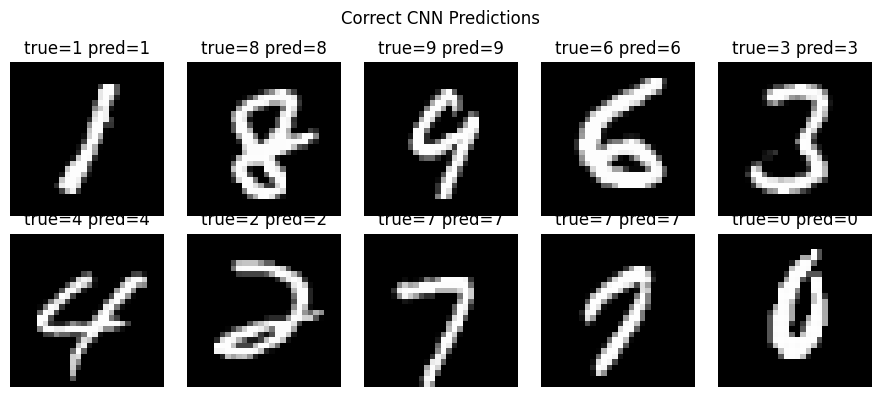

No examples available for: Incorrect CNN Predictions


In [90]:
def plot_prediction_grid(images_to_plot, labels_to_plot, preds_to_plot, title):
    count = min(10, len(labels_to_plot))
    if count == 0:
        print(f"No examples available for: {title}")
        return

    fig, axes = plt.subplots(2, 5, figsize=(9, 4))
    for ax, img, label, pred in zip(
        axes.ravel(), images_to_plot[:count], labels_to_plot[:count], preds_to_plot[:count]
    ):
        ax.imshow(img.squeeze(), cmap="gray")
        ax.set_title(f"true={label.item()} pred={pred.item()}")
        ax.axis("off")

    for ax in axes.ravel()[count:]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_prediction_grid(
    pred_images[correct_mask],
    pred_labels[correct_mask],
    pred_classes[correct_mask],
    "Correct CNN Predictions",
)

plot_prediction_grid(
    pred_images[incorrect_mask],
    pred_labels[incorrect_mask],
    pred_classes[incorrect_mask],
    "Incorrect CNN Predictions",
)


## Session 2: Autoencoders and Latent Space

Goal for this session: use the same PyTorch building blocks for unsupervised reconstruction. Learners should leave able to explain encoder, decoder, bottleneck, reconstruction loss, and a 2D latent-space plot.

## 4. Autoencoder

An autoencoder learns without digit labels. The input image is also the target. The encoder compresses the image into a smaller latent vector, and the decoder tries to reconstruct the original image.


In [103]:
# TODO 7: Build an encoder and decoder with a 2D latent space.
# Fill in the Linear layer parameters.
# Hint: one 28x28 MNIST image has 28 * 28 = 784 pixels after flattening.
# Hint: latent_dim is already set to 2 for visualization.

latent_dim = 16

encoder = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=28 * 28, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=latent_dim,
).to(device))

decoder = nn.Sequential(
    nn.Linear(in_features=latent_dim, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=28 * 28),
    nn.Sigmoid(),
).to(device)

print(encoder)
print(decoder)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=16, bias=True)
)
Sequential(
  (0): Linear(in_features=16, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=784, bias=True)
  (3): Sigmoid()
)


### Understanding Check: Autoencoder

Answer in 2-3 short sentences before training:

1. Why does the decoder end with `Sigmoid()`?
- The decoder end with 'Sigmoid()' because the recosntructed pixel values should stay between o and 1. This matches the normalized image values produced by the ToTensor transform.
2. Why is a 2D latent space useful for visualization?
- A 2D latent space is useful for visualization because it allows the encoded representations to be plotted directly on a two-dimensional graph. This makes it easier to observe clustering patterns between different digit classes.
3. What information might be lost when a 784-pixel image is compressed to two numbers?
- Compressing an image into only two values can remove fine details and small visual differences between digits. Some important shape and texture information may be lost during compression.


In [104]:
# TODO 8: Train the autoencoder to reconstruct its input.
# The target is the flattened original image, not the digit label.
# Complete the same PyTorch loop order used for the CNN.

ae_loss_fn = nn.MSELoss()
ae_optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LEARNING_RATE,
)

ae_history = []
for epoch in range(1, AUTOENCODER_EPOCHS + 1):
    encoder.train()
    decoder.train()
    running_loss = 0.0
    total = 0

    for batch_images, _ in train_loader:
        batch_images = batch_images.to(device)
        flat_images = batch_images.view(batch_images.size(0), -1)

        # Clear old gradients.
        ae_optimizer.zero_grad()
        # Encode the image batch into z.
        z = encoder(batch_images)
        # Decode z back into flattened pixel values.
        recon_flat = decoder(z)
        # Compare reconstructed pixels to the original flattened image.
        loss = ae_loss_fn(recon_flat, flat_images)
        # Backpropagate and update encoder/decoder weights.
        loss.backward()
        ae_optimizer.step()

        running_loss += loss.item() * batch_images.size(0)
        total += batch_images.size(0)

    epoch_loss = running_loss / total
    ae_history.append({"epoch": epoch, "loss": epoch_loss})
    print(f"Epoch {epoch}: reconstruction loss={epoch_loss:.4f}")

Epoch 1: reconstruction loss=0.0726
Epoch 2: reconstruction loss=0.0389
Epoch 3: reconstruction loss=0.0310
Epoch 4: reconstruction loss=0.0257
Epoch 5: reconstruction loss=0.0222
Epoch 6: reconstruction loss=0.0204
Epoch 7: reconstruction loss=0.0191
Epoch 8: reconstruction loss=0.0182
Epoch 9: reconstruction loss=0.0176
Epoch 10: reconstruction loss=0.0170
Epoch 11: reconstruction loss=0.0166
Epoch 12: reconstruction loss=0.0162
Epoch 13: reconstruction loss=0.0159
Epoch 14: reconstruction loss=0.0156
Epoch 15: reconstruction loss=0.0153
Epoch 16: reconstruction loss=0.0151
Epoch 17: reconstruction loss=0.0149
Epoch 18: reconstruction loss=0.0146
Epoch 19: reconstruction loss=0.0144
Epoch 20: reconstruction loss=0.0143


In [105]:
encoder.eval()
decoder.eval()
recon_images, recon_labels = next(iter(test_loader))
recon_images = recon_images[:10].to(device)

with torch.no_grad():
    z = encoder(recon_images)
    recon_flat = decoder(z)
    recon_view = recon_flat.view(-1, 1, 28, 28).cpu()

original_view = recon_images.cpu()


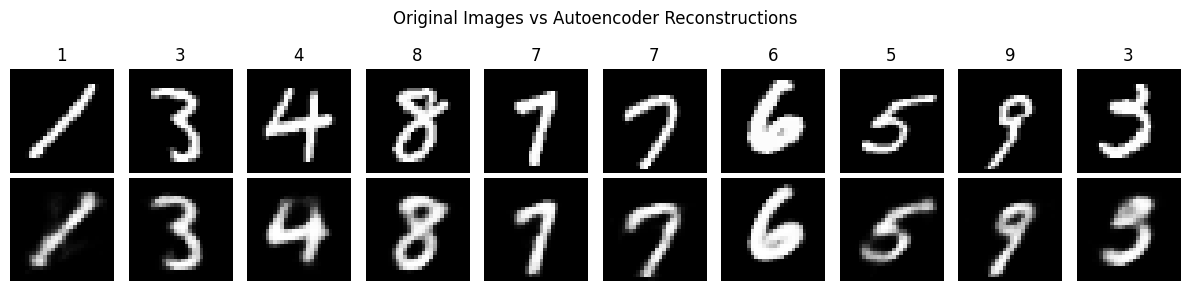

In [106]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for idx in range(10):
    axes[0, idx].imshow(original_view[idx].squeeze(), cmap="gray")
    axes[0, idx].axis("off")
    axes[0, idx].set_title(f"{recon_labels[idx].item()}")

    axes[1, idx].imshow(recon_view[idx].squeeze(), cmap="gray")
    axes[1, idx].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Recon")
fig.suptitle("Original Images vs Autoencoder Reconstructions")
plt.tight_layout()
plt.show()


## 5. Latent Space Visualization

Because `latent_dim = 2`, every test image is compressed to an `(x, y)` point. Coloring each point by its true digit label lets us inspect whether the unsupervised autoencoder learned useful structure.


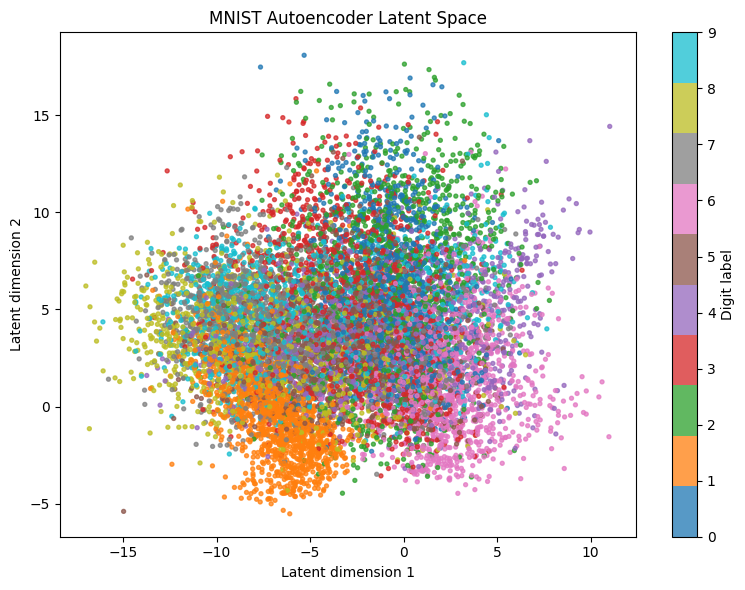

In [107]:
# TODO 9: Encode test images and plot the 2D latent space.
# Fill in the encoder call, CPU conversion, and scatter x/y coordinates.

encoder.eval()
latent_points = []
latent_labels = []

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        z = encoder(batch_images) # Use encoder on batch_images.
        latent_points.append(z.cpu())  # Move z back to CPU before storing it.
        latent_labels.append(batch_labels)  # Store the labels for coloring points.

latent_points = torch.cat(latent_points).numpy()
latent_labels = torch.cat(latent_labels).numpy()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latent_points[:, 0],  # x coordinate: first latent dimension
    latent_points[:, 1],  # y coordinate: second latent dimension
    c=latent_labels,
    cmap="tab10",
    s=8,
    alpha=0.75,
)
plt.colorbar(scatter, ticks=range(10), label="Digit label")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("MNIST Autoencoder Latent Space")
plt.tight_layout()
plt.show()

## Reflection

Answer each prompt in 2-3 short sentences. Use the plots, model accuracy, reconstruction images, and latent-space scatter plot as evidence.

1. Why are CNNs better matched to image data than a fully flattened input?
- CNNs better matched to image data than a fully flattened input because it preserve the spatial structure of images by processing nearby pizels together. This allows the model to learn local patterns such as edges, curves, and shapes more effectively.
2. What did the manual kernel reveal about local image patterns?
- The manual kernel reveal about edges and intensity changes in the image. It showed how convolution can detect important visual patterns from neighboring pizels.
3. What did the CNN learn that the manual kernel did not?
- The CNN learn more complex and meaningful features through training as compared to manual kernel because the CNN adapted its filters to improve digit classification accuracy.
4. What did the autoencoder learn without using labels?
- The autoencoder learn compressed representations of digit images without using labels by reconstructing the original inputs. Also, even without using labels, it can still discover meaningful visual structures and similarities between digits.
5. Which digits appeared close together in latent space, and why might that happen?
- Digits with similar shapes, such as 3 and 8 or 4 and 9, appeared closer together in latent space. This happened because the autoencoder grouped ikages based on visual similarity rather than label information.
